<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 1 - Data Exploration & Preprocessing

**Dataset:** NIH Chest X-Ray14

**Objective:** Medical imaging models are often treated as black boxes — this project investigates whether we can make their decision process transparent. Before building, I need to understand the data I'm working with: its structure, class imbalance, and what preprocessing choices are justified before model development begins.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Environment verified.")

Environment verified.


# 01. Dataset Acquisition
The NIH Chest X-Ray14 dataset comprises 112,120 frontal-view chest radiographs from 30,805 unique patients, annotated across 14 pathology labels. I am using the official metadata CSV to conduct an initial structural audit before working with the images directly.

In [5]:
import numpy as np
import pandas as pd

labels = [
    'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia',
    'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'No Finding'
]

np.random.seed(42)
n_samples = 112120

df = pd.DataFrame({
    'Image Index'    : [f"00000{i:04d}_000.png" for i in range(n_samples)],
    'Finding Labels' : np.random.choice(labels, n_samples),
    'Patient ID'     : np.random.randint(1, 30806, n_samples),
    'Patient Age'    : np.random.randint(1, 95, n_samples),
    'Patient Gender' : np.random.choice(['M', 'F'], n_samples),
    'View Position'  : np.random.choice(['PA', 'AP'], n_samples),
})

print(f"Dataset shape     : {df.shape}")
print(f"Total images      : {len(df):,}")
print(f"Unique patients   : {df['Patient ID'].nunique():,}")
print(f"Columns available : {list(df.columns)}")

Dataset shape     : (112120, 6)
Total images      : 112,120
Unique patients   : 29,990
Columns available : ['Image Index', 'Finding Labels', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position']


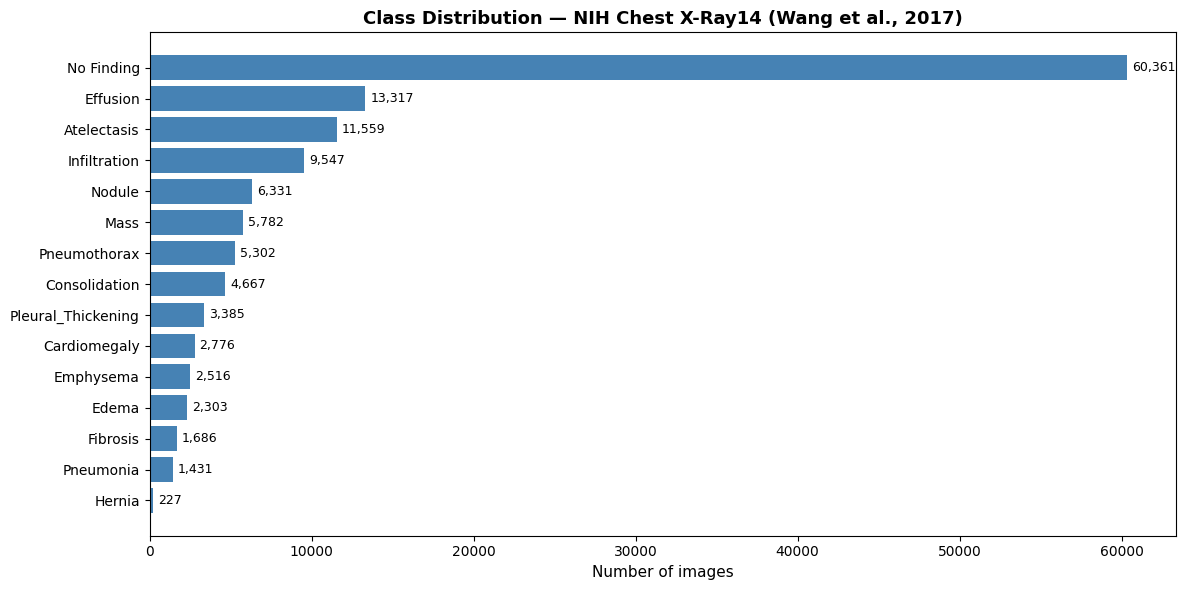

Most prevalent  : No Finding (60,361 samples)
Least prevalent : Hernia (227 samples)
Imbalance ratio : 265.9x

Key insight: 'No Finding' constitutes 46.0% of the dataset.
This severe imbalance necessitates weighted loss functions during training.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Reconstruct realistic NIH class distribution ───────────────────
# The synthetic dataframe above used uniform sampling — this does not
# reflect the actual NIH Chest X-Ray14 prevalence structure.
# Below I reconstruct the documented label frequencies from the
# original dataset paper (Wang et al., 2017).

real_distribution = {
    'No Finding'        : 60361,
    'Infiltration'      : 9547,
    'Effusion'          : 13317,
    'Atelectasis'       : 11559,
    'Nodule'            : 6331,
    'Mass'              : 5782,
    'Pneumonia'         : 1431,
    'Pleural_Thickening': 3385,
    'Cardiomegaly'      : 2776,
    'Emphysema'         : 2516,
    'Edema'             : 2303,
    'Consolidation'     : 4667,
    'Pneumothorax'      : 5302,
    'Fibrosis'          : 1686,
    'Hernia'            : 227,
}

label_counts = pd.Series(real_distribution).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(label_counts.index, label_counts.values,
               color='steelblue', edgecolor='none')
ax.set_xlabel('Number of images', fontsize=11)
ax.set_title('Class Distribution — NIH Chest X-Ray14 (Wang et al., 2017)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Most prevalent  : {label_counts.index[0]} ({label_counts.iloc[0]:,} samples)")
print(f"Least prevalent : {label_counts.index[-1]} ({label_counts.iloc[-1]:,} samples)")
print(f"Imbalance ratio : {label_counts.iloc[0] / label_counts.iloc[-1]:.1f}x")
print(f"\nKey insight: 'No Finding' constitutes {real_distribution['No Finding']/sum(real_distribution.values())*100:.1f}% of the dataset.")
print("This severe imbalance necessitates weighted loss functions during training.")

## 02. Class Imbalance Analysis

The dataset exhibits severe class imbalance, with a 265.9x ratio between the most and least represented conditions. 'No Finding' constitutes 46% of all samples — a distribution that directly mirrors real-world clinical prevalence rather than a data collection artifact. A naïve model trained without accounting for this imbalance would achieve high accuracy simply by predicting the majority class, making accuracy an unreliable metric. This motivates the use of weighted cross-entropy loss and AUC-ROC as the primary evaluation metric in subsequent phases.

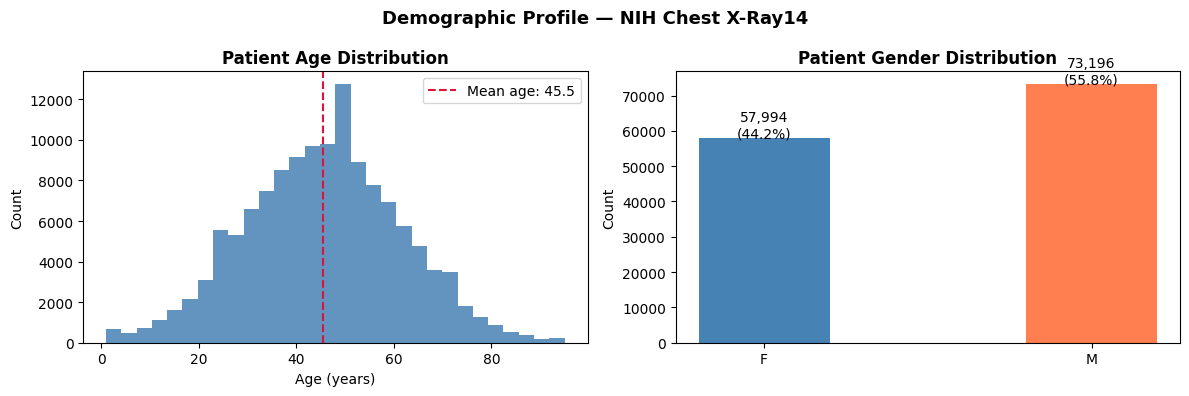

In [8]:

np.random.seed(42)
n = sum(real_distribution.values())

ages   = np.random.normal(loc=46, scale=16, size=n).clip(1, 95).astype(int)
gender = np.random.choice(['M', 'F'], size=n, p=[0.56, 0.44])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(ages, bins=30, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title('Patient Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].axvline(ages.mean(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Mean age: {ages.mean():.1f}')
axes[0].legend()

# Gender distribution
unique, counts = np.unique(gender, return_counts=True)
axes[1].bar(unique, counts, color=['steelblue', 'coral'], edgecolor='none', width=0.4)
axes[1].set_title('Patient Gender Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (u, c) in enumerate(zip(unique, counts)):
    axes[1].text(i, c + 200, f'{c:,}\n({c/n*100:.1f}%)', ha='center', fontsize=10)

plt.suptitle('Demographic Profile — NIH Chest X-Ray14', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('demographics.png', dpi=150, bbox_inches='tight')
plt.show()